In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

mu = 1.0 
a = 0.5   
mu1 = np.array([mu, 0.0])
mu_s = np.array([a, 0.0])  

theta_star = np.array([mu/(mu**2 + 2), 0.0])

n1_values = np.array([6, 12, 25, 50, 100, 200, 400, 800, 1600, 3200])  
imbalance_ratio = 20  
repetitions = 100 

test_size_per_class = 5000


def generate_data(n0, n1, syn_size, mu1, mu_s):
    X0 = np.random.randn(n0, 2) 
    X1 = np.random.randn(n1, 2) + mu1  
    
    X_syn = np.random.randn(syn_size, 2) + mu_s
    
    X_train = np.vstack([X0, X1, X_syn])
    y_train = np.hstack([np.zeros(n0), np.ones(n1), np.ones(syn_size)])
    
    return X_train, y_train

def compute_theta_hat(X_train, y_train):
    ridge = 1e-6
    theta = np.linalg.solve(X_train.T @ X_train + ridge * np.eye(2), X_train.T @ y_train)
    return theta

def compute_balanced_risk(theta, mu1):
    term1 = theta @ theta
    term2 = 0.5 * (theta @ mu1 - 1)**2
    return term1 + term2

def compute_excess_risk(theta, mu1):
    R0_theta = compute_balanced_risk(theta, mu1)
    R0_star = compute_balanced_risk(theta_star, mu1)
    return R0_theta - R0_star

def compute_test_loss(theta, X_test, y_test):
    y_pred = X_test @ theta
    mse = np.mean((y_pred - y_test)**2)
    return mse

metrics_optimal = {
    'excess_risk': [],
    'param_error': []
}

metrics_balanced = {
    'excess_risk': [],
    'param_error': []
}

for n1 in n1_values:
    n0 = int(n1 * imbalance_ratio)
    syn_balanced = n0 - n1  
    syn_optimal = int(4 * (n0 - n1))  
    
    temp_opt = {'excess_risk': [], 'param_error': []}
    temp_bal = {'excess_risk': [], 'param_error': []}
    
    for rep in range(repetitions):
        X_test0 = np.random.randn(test_size_per_class, 2)
        X_test1 = np.random.randn(test_size_per_class, 2) + mu1
        X_test = np.vstack([X_test0, X_test1])
        y_test = np.hstack([np.zeros(test_size_per_class), np.ones(test_size_per_class)])
        
        X_train_opt, y_train_opt = generate_data(n0, n1, syn_optimal, mu1, mu_s)
        theta_opt = compute_theta_hat(X_train_opt, y_train_opt)
        
        temp_opt['excess_risk'].append(compute_excess_risk(theta_opt, mu1))
        temp_opt['param_error'].append(np.linalg.norm(theta_opt - theta_star))
        
        X_train_bal, y_train_bal = generate_data(n0, n1, syn_balanced, mu1, mu_s)
        theta_bal = compute_theta_hat(X_train_bal, y_train_bal)
        
        temp_bal['excess_risk'].append(compute_excess_risk(theta_bal, mu1))
        temp_bal['param_error'].append(np.linalg.norm(theta_bal - theta_star))
    
    for metric in ['excess_risk', 'param_error']:
        metrics_optimal[metric].append({
            'mean': np.mean(temp_opt[metric]),
            'std': np.std(temp_opt[metric])
        })
        metrics_balanced[metric].append({
            'mean': np.mean(temp_bal[metric]),
            'std': np.std(temp_bal[metric])
        })
    
    print(f"Completed n1 = {n1}: "
          f"Optimal excess risk = {metrics_optimal['excess_risk'][-1]['mean']:.4f}, "
          f"Balanced excess risk = {metrics_balanced['excess_risk'][-1]['mean']:.4f}")


Completed n1 = 6: Optimal excess risk = 0.0020, Balanced excess risk = 0.0192
Completed n1 = 12: Optimal excess risk = 0.0012, Balanced excess risk = 0.0196
Completed n1 = 25: Optimal excess risk = 0.0005, Balanced excess risk = 0.0165
Completed n1 = 50: Optimal excess risk = 0.0002, Balanced excess risk = 0.0165
Completed n1 = 100: Optimal excess risk = 0.0001, Balanced excess risk = 0.0168
Completed n1 = 200: Optimal excess risk = 0.0001, Balanced excess risk = 0.0164
Completed n1 = 400: Optimal excess risk = 0.0000, Balanced excess risk = 0.0161
Completed n1 = 800: Optimal excess risk = 0.0000, Balanced excess risk = 0.0162
Completed n1 = 1600: Optimal excess risk = 0.0000, Balanced excess risk = 0.0162
Completed n1 = 3200: Optimal excess risk = 0.0000, Balanced excess risk = 0.0161


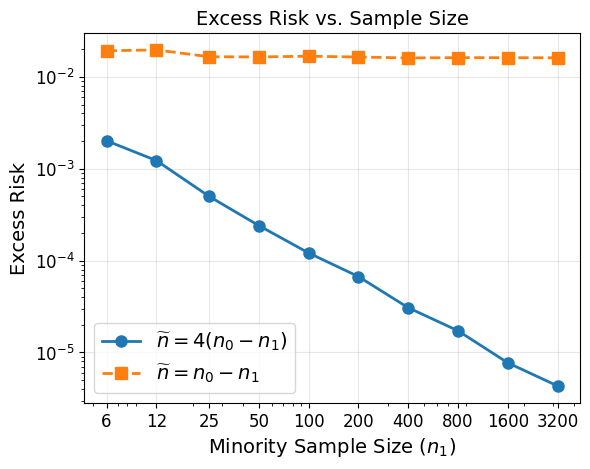

In [51]:
n1_array = n1_values
optimal_means = {m: [x['mean'] for x in metrics_optimal[m]] for m in metrics_optimal}
optimal_stds = {m: [x['std'] for x in metrics_optimal[m]] for m in metrics_optimal}
balanced_means = {m: [x['mean'] for x in metrics_balanced[m]] for m in metrics_balanced}
balanced_stds = {m: [x['std'] for x in metrics_balanced[m]] for m in metrics_balanced}


plt.errorbar(n1_array, optimal_means['excess_risk'],
             fmt='o-', capsize=5, label='$\widetilde{n}=4(n_0-n_1)$', linewidth=2, markersize=8)
plt.errorbar(n1_array, balanced_means['excess_risk'],
             fmt='s--', capsize=5, label='$\widetilde{n}=n_0-n_1$', linewidth=2, markersize=8)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Minority Sample Size ($n_1$)', fontsize=14)
plt.ylabel('Excess Risk', fontsize=14)
plt.title('Excess Risk vs. Sample Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=14)
plt.xticks(n1_array, [str(x) for x in n1_array], fontsize=12)
plt.yticks(fontsize=12)
plt.show()



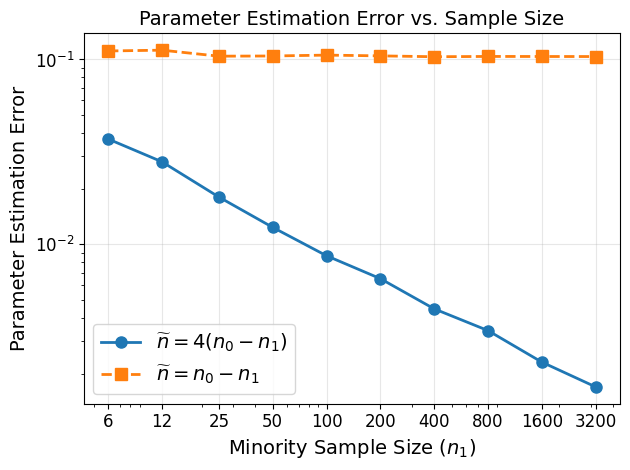

In [52]:
plt.errorbar(n1_array, optimal_means['param_error'],
             fmt='o-', capsize=5, label='$\widetilde{n}=4(n_0-n_1)$', linewidth=2, markersize=8)
plt.errorbar(n1_array, balanced_means['param_error'],
             fmt='s--', capsize=5, label='$\widetilde{n}=n_0-n_1$', linewidth=2, markersize=8)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Minority Sample Size ($n_1$)', fontsize=14)
plt.ylabel('Parameter Estimation Error', fontsize=14)
plt.title('Parameter Estimation Error vs. Sample Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=14)
plt.xticks(n1_array, [str(x) for x in n1_array], fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()